# Global DQN Model — 300 Ausgrid Households

Trains a **single shared DQN agent** on 295 household datasets and evaluates it on 10 randomly chosen datasets:
- 5 **seen** (included in training)
- 5 **unseen** (held out from training entirely)

For every dataset the first 2/3 of timesteps are training data and the last 1/3 is the evaluation window.

## Cell 1 — Imports & device

In [3]:
import os
import sys
import copy
import json
import random
import importlib
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pulp

import torch as T
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from collections import deque
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

import Environment as environment_module
importlib.reload(environment_module)
HouseholdEnvironment = environment_module.HouseholdEnvironment

from Basic_Functions import calculate_interval_price
from Ploting_Functions import plotMultiY

# Device selection
if T.cuda.is_available():
    device = T.device('cuda')
    print(f'NVIDIA CUDA: {T.cuda.get_device_name(0)}')
elif T.backends.mps.is_available():
    device = T.device('mps')
    print('Apple Silicon MPS')
else:
    device = T.device('cpu')
    print('CPU')

CPU


## Cell 2 — Configuration

In [4]:
# ── Experiment ──────────────────────────────────────────────
SEED         = 42
N_HOLDOUT    = 5    # users withheld from training
N_EVAL_SEEN  = 5    # seen users selected for evaluation
DATA_DIR     = 'Datasorted by user'

# ── Physics (30-min step → scale rate limits accordingly) ───
BASE_STEP_MINUTES    = 15.0
DATASET_STEP_MINUTES = 30.0
step_scale           = DATASET_STEP_MINUTES / BASE_STEP_MINUTES  # = 2.0

KorakovNaDan     = int(round(1440 / DATASET_STEP_MINUTES))  # 48
BatKapaciteta    = 20.0
BatUcinkovitost  = 0.95
BatMaxPolnjenje  = 1.5 * step_scale   # 3.0 kWh/step
BatMaxPraznjenje = 1.5 * step_scale   # 3.0 kWh/step
faktorN1, faktorN2, faktorN3 = 0, 0, 1

# ── DQN hyper-parameters (best from single-user notebook) ───
fc1_dims, fc2_dims, fc3_dims = 256, 128, 64
lr             = 0.001
gamma          = 0.99
epsilon_start  = 1.0
epsilon_end    = 0.01
epsilon_decay  = 4e-5/4
batch_size     = 48
replace_target = KorakovNaDan * 7   # 336 steps
weight_decay   = 1e-4

# ── Training schedule ───────────────────────────────────────
N_ROUNDS           = 40*4   # outer rounds
EPISODES_PER_ROUND = 10   # users sampled per round
EPISODE_STEPS      = KorakovNaDan * 7  # 1 week per episode

print(f'KorakovNaDan={KorakovNaDan}  BatMaxPol={BatMaxPolnjenje}  BatMaxPra={BatMaxPraznjenje}')

KorakovNaDan=48  BatMaxPol=3.0  BatMaxPra=3.0


## Cell 3 — Reproducible user split

In [5]:
rng = np.random.default_rng(SEED)

all_ids = list(range(1, 301))
rng.shuffle(all_ids)

holdout_ids = all_ids[:N_HOLDOUT]          # 5 unseen users
train_ids   = all_ids[N_HOLDOUT:]          # 295 training users

eval_seen   = rng.choice(train_ids, N_EVAL_SEEN, replace=False).tolist()
eval_unseen = holdout_ids                   # all 5 holdout users
eval_ids    = eval_seen + eval_unseen       # 10 total

print(f'Training users : {len(train_ids)}')
print(f'Holdout users  : {holdout_ids}')
print(f'Eval seen      : {eval_seen}')
print(f'Eval unseen    : {eval_unseen}')

Training users : 295
Holdout users  : [262, 294, 62, 254, 167]
Eval seen      : [242, 215, 43, 93, 19]
Eval unseen    : [262, 294, 62, 254, 167]


## Cell 4 — Load & split all 300 datasets

In [6]:
def load_ausgrid(uid):
    path = os.path.join(DATA_DIR, f'Ausgrid {uid}.csv')
    df = pd.read_csv(path)
    df.index = pd.to_datetime(df['Timestamp_UTC'], format='ISO8601')
    df = df.drop(columns=['Timestamp_UTC'])
    return df

print('Loading 300 datasets...')
train_dfs = {}
test_dfs  = {}

for uid in range(1, 301):
    df = load_ausgrid(uid)
    split = int(len(df) * 2 / 3)
    train_dfs[uid] = df.iloc[:split].copy()
    test_dfs[uid]  = df.iloc[split:].copy()

sample = train_dfs[1]
print(f'Loaded. Train rows: {len(sample)}  Test rows: {len(test_dfs[1])}')
print(f'Columns: {sample.columns.tolist()}')
print(f'Date range (train user 1): {sample.index[0]} → {sample.index[-1]}')

Loading 300 datasets...
Loaded. Train rows: 35072  Test rows: 17536
Columns: ['Energy_Consumption', 'Energy_Generation', 'SMP']
Date range (train user 1): 2010-07-01 00:30:00+00:00 → 2012-06-30 16:00:00+00:00


## Cell 5 — Global normalization (no data leakage)

In [7]:
# ── 5a. SMP price normalization ─────────────────────────────
# SMP is identical across all datasets; fit once on the training portion.

def normalize_electricity_prices(data, fit=False, params=None):
    """Log + clip + RobustScaler for SMP. Identical to single-user notebook."""
    if data.ndim == 1:
        data = data.reshape(-1, 1)

    if fit:
        upper_threshold = np.percentile(data, 99.5)
        lower_threshold = np.percentile(data, 0.1)
    else:
        upper_threshold = params['upper_threshold']
        lower_threshold = params['lower_threshold']

    outlier_flag = ((data > upper_threshold) | (data < lower_threshold)).astype(float)
    log_data     = np.log1p(np.maximum(data, 0))
    log_lower    = np.log1p(max(0, lower_threshold))
    log_upper    = np.log1p(max(0, upper_threshold))
    clipped      = np.clip(log_data, log_lower, log_upper)

    if fit:
        scaler = RobustScaler()
        normalized = scaler.fit_transform(clipped)
        fitted_params = {
            'upper_threshold': float(upper_threshold),
            'lower_threshold': float(lower_threshold),
            'log_lower': float(log_lower),
            'log_upper': float(log_upper),
            'scaler': scaler,
        }
    else:
        normalized    = params['scaler'].transform(clipped)
        fitted_params = params

    return normalized, outlier_flag, fitted_params

# Fit SMP scaler on training portion of user 1 (SMP identical for all)
smp_train_ref = train_dfs[train_ids[0]]['SMP'].values
_, _, price_norm_params = normalize_electricity_prices(smp_train_ref, fit=True)
print('SMP price scaler fitted.')

# ── 5b. Energy (Gen + Con) global scaler ────────────────────
# Concatenate ALL training portions to learn a global distribution.
shared_cols = ['Energy_Generation', 'Energy_Consumption']

print('Building global energy scaler (concatenating 295 training sets)...')
combined_energy = np.concatenate([
    train_dfs[uid][shared_cols].values.flatten()
    for uid in train_ids
]).reshape(-1, 1)

global_energy_scaler = RobustScaler()
global_energy_scaler.fit(combined_energy)
print('Energy scaler fitted.')

# ── 5c. Apply to every dataset (train + test) ───────────────
def apply_normalization(df, split_label, uid):
    """Return a fully normalised copy of df."""
    df_n = df.copy()

    # Energy columns
    for col in shared_cols:
        df_n[col] = global_energy_scaler.transform(
            df[col].values.reshape(-1, 1)
        ).flatten()

    # SMP
    smp_norm, smp_flag, _ = normalize_electricity_prices(
        df['SMP'].values, fit=False, params=price_norm_params
    )
    df_n['SMP'] = smp_norm.flatten()
    df_n['SMP_OutlierFlag'] = smp_flag.flatten()

    return df_n

print('Normalising all 300 datasets (train + test)...')
train_norm_dfs = {uid: apply_normalization(train_dfs[uid], 'train', uid) for uid in range(1, 301)}
test_norm_dfs  = {uid: apply_normalization(test_dfs[uid],  'test',  uid) for uid in range(1, 301)}

print('Done.')
print('Sample normalised train stats (user 1):')
print(train_norm_dfs[1][['Energy_Consumption', 'Energy_Generation', 'SMP']].describe().round(3))

SMP price scaler fitted.
Building global energy scaler (concatenating 295 training sets)...
Energy scaler fitted.
Normalising all 300 datasets (train + test)...
Done.
Sample normalised train stats (user 1):
       Energy_Consumption  Energy_Generation        SMP
count           35072.000          35072.000  35072.000
mean                0.673              0.515      0.368
std                 1.020              1.462      1.578
min                -0.397             -0.397     -3.552
25%                -0.017             -0.397     -0.257
50%                 0.267             -0.397      0.000
75%                 1.027              1.000      0.743
max                 8.537              5.730     12.568


## Cell 6 — Environment factory

In [8]:
def make_env(uid, split='train', episode_length=None):
    """Create a HouseholdEnvironment for the given user and data split."""
    if split == 'train':
        data   = train_dfs[uid]
        data_n = train_norm_dfs[uid]
        reset_mode = 'random'
        ep_len = episode_length if episode_length is not None else EPISODE_STEPS
    else:
        data   = test_dfs[uid]
        data_n = test_norm_dfs[uid]
        reset_mode = 'deterministic'
        ep_len = episode_length if episode_length is not None else len(data) - 1

    return HouseholdEnvironment(
        dataset          = data,
        dataset_norm     = data_n,
        observation_mode = 'sliding_window',
        reset_mode       = reset_mode,
        episode_length   = ep_len,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = BatKapaciteta,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )

# Verify state dimension
_tmp_env = make_env(1, split='train')
STATE_DIM = int(_tmp_env.observation_space.shape[0])
NETWORK_DIMS = [STATE_DIM, fc1_dims, fc2_dims, fc3_dims, 5] #, fc4_dims 
print(f'State dim: {STATE_DIM}  (window_past={_tmp_env.window_past}, window_future={_tmp_env.window_future})')

State dim: 25  (window_past=0, window_future=22)


## Cell 7 — DQN agent (data-agnostic, copied from single-user notebook)

In [9]:
class DeepQNetwork(nn.Module):
    def __init__(self, lr, layer_dims, weight_decay=1e-4):
        super().__init__()
        self.layer_dims = list(layer_dims)
        self.layers = nn.ModuleList([
            nn.Linear(in_d, out_d)
            for in_d, out_d in zip(self.layer_dims[:-1], self.layer_dims[1:])
        ])
        self.optimizer = optim.AdamW(self.parameters(), lr=lr, weight_decay=weight_decay)
        self.loss = nn.SmoothL1Loss(beta=1.0)
        self.device = T.device('cuda' if T.cuda.is_available() else
                               'mps'  if T.backends.mps.is_available() else 'cpu')
        nn.init.constant_(self.layers[-1].bias, 0.1)
        self.to(self.device)

    def forward(self, state):
        x = state
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)


class AgentDQN:
    def __init__(self, gamma, epsilon, lr, state_shape, network_dims,
                 batch_size, replace_target=336, max_mem_size=1_000_000,
                 eps_end=0.05, eps_dec=4e-5, weight_decay=1e-4, tau=0.005):
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.eps_min       = eps_end
        self.eps_dec       = eps_dec
        self.lr            = lr
        self.batch_size    = batch_size
        self.mem_size      = max_mem_size
        self.mem_cntr      = 0
        self.iter_cntr     = 0
        self.replace_target = replace_target
        self.tau           = float(tau)
        self.state_shape   = list(state_shape)
        self.network_dims  = list(network_dims)
        self.n_actions     = self.network_dims[-1]
        self.action_space  = list(range(self.n_actions))
        self.start_learning_after = int(4 * batch_size)

        self.Q_eval   = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target = DeepQNetwork(lr=lr, layer_dims=self.network_dims, weight_decay=weight_decay)
        self.Q_target.load_state_dict(self.Q_eval.state_dict())
        self.Q_target.eval()

        self.state_memory     = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.new_state_memory = np.zeros((self.mem_size, *self.state_shape), dtype=np.float32)
        self.action_memory    = np.zeros(self.mem_size, dtype=np.int32)
        self.reward_memory    = np.zeros(self.mem_size, dtype=np.float32)
        self.terminal_memory  = np.zeros(self.mem_size, dtype=np.bool_)

    def store_transition(self, state, action, reward, state_, terminal):
        idx = self.mem_cntr % self.mem_size
        self.state_memory[idx]     = state
        self.new_state_memory[idx] = state_
        self.reward_memory[idx]    = reward
        self.action_memory[idx]    = action
        self.terminal_memory[idx]  = terminal
        self.mem_cntr += 1

    def choose_action(self, observation):
        if np.random.random() > self.epsilon:
            state   = T.tensor(np.array([observation]), dtype=T.float32).to(self.Q_eval.device)
            actions = self.Q_eval.forward(state)
            return int(T.argmax(actions).item())
        return np.random.choice(self.action_space)

    def _soft_update_target(self):
        with T.no_grad():
            for tp, ep in zip(self.Q_target.parameters(), self.Q_eval.parameters()):
                tp.data.mul_(1.0 - self.tau).add_(self.tau * ep.data)

    def learn(self):
        if self.mem_cntr < self.start_learning_after:
            return
        max_mem = min(self.mem_cntr, self.mem_size)
        if max_mem < self.batch_size:
            return

        batch       = np.random.choice(max_mem, self.batch_size, replace=False)
        batch_index = np.arange(self.batch_size, dtype=np.int32)

        dev = self.Q_eval.device
        s   = T.tensor(self.state_memory[batch],     dtype=T.float32, device=dev)
        s_  = T.tensor(self.new_state_memory[batch], dtype=T.float32, device=dev)
        a   = T.tensor(self.action_memory[batch],    dtype=T.long,    device=dev)
        r   = T.tensor(self.reward_memory[batch],    dtype=T.float32, device=dev)
        t   = T.tensor(self.terminal_memory[batch],  dtype=T.float32, device=dev)

        q_eval = self.Q_eval(s)[batch_index, a]

        with T.no_grad():
            next_a  = self.Q_eval(s_).argmax(dim=1, keepdim=True)
            q_next  = self.Q_target(s_).gather(1, next_a).squeeze(1)
            q_target = r + self.gamma * q_next * (1 - t)

        loss = self.Q_eval.loss(q_eval, q_target).to(dev)
        self.Q_eval.optimizer.zero_grad()
        loss.backward()
        T.nn.utils.clip_grad_norm_(self.Q_eval.parameters(), max_norm=1.0)
        self.Q_eval.optimizer.step()

        self.iter_cntr += 1
        self.epsilon = max(self.epsilon - self.eps_dec, self.eps_min)

        if self.tau > 0.0:
            self._soft_update_target()
        elif self.iter_cntr % self.replace_target == 0:
            self.Q_target.load_state_dict(self.Q_eval.state_dict())

#print(f'Network dims: [{STATE_DIM}, {fc1_dims}, {fc2_dims}, {fc3_dims}, {fc4_dims}, 5]')

## Cell 8 — Global training loop

In [10]:
import time



agent = AgentDQN(
    gamma          = gamma,
    epsilon        = epsilon_start,
    lr             = lr,
    state_shape    = [STATE_DIM],
    network_dims   = NETWORK_DIMS,
    batch_size     = batch_size,
    replace_target = replace_target,
    eps_end        = epsilon_end,
    eps_dec        = epsilon_decay,
    weight_decay   = weight_decay,
)

def train_global_dqn(agent, train_ids, n_rounds=N_ROUNDS, episodes_per_round=EPISODES_PER_ROUND):
    """
    Each round randomly samples `episodes_per_round` users from train_ids
    and runs one week-long episode per user. The agent accumulates experience
    in a single shared replay buffer across all users.
    """
    round_rewards = []

    for round_i in range(n_rounds):
        t0 = time.time()
        sampled_uids = rng.choice(train_ids, episodes_per_round, replace=True)
        round_reward = 0.0
        episodes_done = 0

        for uid in sampled_uids:
            env = make_env(uid, split='train', episode_length=EPISODE_STEPS)
            obs, _ = env.reset()
            ep_reward = 0.0

            for _ in range(EPISODE_STEPS):
                action = agent.choose_action(obs)
                next_obs, reward, terminated, truncated, _ = env.step(action)
                done = bool(terminated or truncated)

                agent.store_transition(obs, action, reward, next_obs, done)
                agent.learn()

                obs = next_obs
                ep_reward += reward

                if done:
                    break

            round_reward += ep_reward
            episodes_done += 1

        avg_reward = round_reward / max(episodes_done, 1)
        round_rewards.append(avg_reward)
        elapsed = time.time() - t0
        print(f'Round {round_i+1:3d}/{n_rounds}  '
              f'avg_reward={avg_reward:7.2f}  '
              f'ε={agent.epsilon:.4f}  '
              f'({elapsed:.1f}s)')

    return agent, round_rewards


print(f'Starting global training: {N_ROUNDS} rounds × {EPISODES_PER_ROUND} episodes...')
agent, training_rewards = train_global_dqn(agent, train_ids)
print(f'\nTraining complete. Final epsilon: {agent.epsilon:.4f}')

Starting global training: 160 rounds × 10 episodes...
Round   1/160  avg_reward= -31.89  ε=0.9684  (8.2s)
Round   2/160  avg_reward= -30.94  ε=0.9349  (8.8s)
Round   3/160  avg_reward= -32.83  ε=0.9014  (9.1s)
Round   4/160  avg_reward= -29.19  ε=0.8679  (9.3s)
Round   5/160  avg_reward= -29.98  ε=0.8344  (9.7s)
Round   6/160  avg_reward= -30.57  ε=0.8009  (9.9s)
Round   7/160  avg_reward= -30.81  ε=0.7674  (10.1s)
Round   8/160  avg_reward= -25.22  ε=0.7339  (10.4s)
Round   9/160  avg_reward= -23.36  ε=0.7004  (10.6s)
Round  10/160  avg_reward= -30.91  ε=0.6669  (10.7s)
Round  11/160  avg_reward= -21.40  ε=0.6334  (11.1s)
Round  12/160  avg_reward= -19.33  ε=0.5999  (11.4s)
Round  13/160  avg_reward= -21.49  ε=0.5664  (11.7s)
Round  14/160  avg_reward= -19.07  ε=0.5329  (11.9s)
Round  15/160  avg_reward= -23.44  ε=0.4994  (12.1s)
Round  16/160  avg_reward= -17.42  ε=0.4659  (12.4s)
Round  17/160  avg_reward= -14.77  ε=0.4324  (12.5s)
Round  18/160  avg_reward= -16.49  ε=0.3989  (12.9s

### Training reward curve

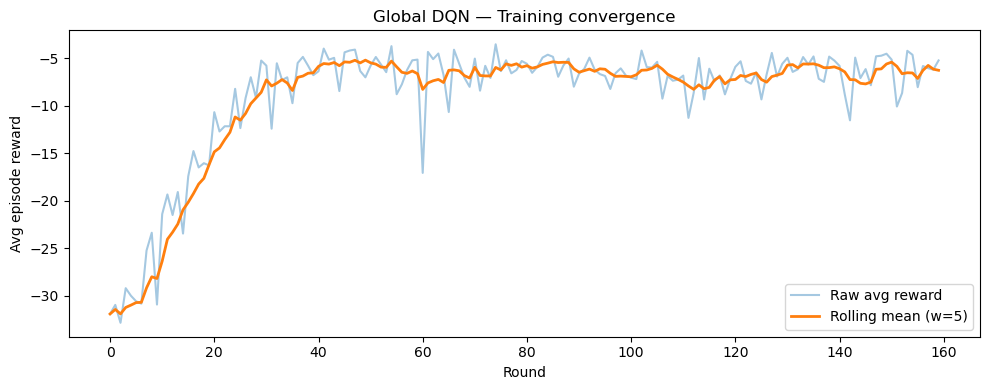

In [11]:
window = 5
trend  = pd.Series(training_rewards).rolling(window=window, min_periods=1).mean().tolist()

plt.figure(figsize=(10, 4))
plt.plot(training_rewards, alpha=0.4, label='Raw avg reward')
plt.plot(trend, linewidth=2, label=f'Rolling mean (w={window})')
plt.xlabel('Round'); plt.ylabel('Avg episode reward')
plt.title('Global DQN — Training convergence')
plt.legend(); plt.tight_layout(); plt.show()

## Cell 9 — Evaluate on 10 datasets (5 seen + 5 unseen)

In [12]:
def evaluate_user(agent, uid, verbose=False):
    """Run one full greedy episode on the test split of `uid`. Returns total cost (AUD)."""
    env = make_env(uid, split='test')
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})

    saved_eps   = agent.epsilon
    agent.epsilon = 0.0

    last_info = {}
    steps = len(test_dfs[uid]) - 1

    for _ in range(steps):
        action = agent.choose_action(obs)
        obs, _, terminated, truncated, info = env.step(action)
        last_info = info
        if terminated or truncated:
            break

    agent.epsilon = saved_eps
    cost = float(last_info.get('cumulative_payment', 0.0))
    if verbose:
        print(f'  User {uid:3d}: {cost:.2f} AUD')
    return cost


def no_battery_baseline(uid):
    """Run the test split with bat_kapaciteta=0 and always action 4 (idle).
    Uses the identical calculate_interval_price cost logic as evaluate_user."""
    env = HouseholdEnvironment(
        dataset          = test_dfs[uid],
        dataset_norm     = test_norm_dfs[uid],
        observation_mode = 'sliding_window',
        reset_mode       = 'deterministic',
        episode_length   = len(test_dfs[uid]) - 1,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = 0,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )
    obs, _ = env.reset(options={'reset_mode': 'deterministic'})
    last_info = {}
    for _ in range(len(test_dfs[uid]) - 1):
        obs, _, terminated, truncated, last_info = env.step(4)  # 4 = idle, no battery
        if terminated or truncated:
            break
    return float(last_info.get('cumulative_payment', 0.0))


print('Evaluating global DQN on 10 datasets...')
results = []

for uid in eval_seen:
    cost     = evaluate_user(agent, uid, verbose=True)
    baseline = no_battery_baseline(uid)
    results.append({'uid': uid, 'group': 'seen', 'cost_aud': cost, 'baseline_aud': baseline})

for uid in eval_unseen:
    cost     = evaluate_user(agent, uid, verbose=True)
    baseline = no_battery_baseline(uid)
    results.append({'uid': uid, 'group': 'unseen', 'cost_aud': cost, 'baseline_aud': baseline})

df_results = pd.DataFrame(results)
df_results['improvement_%'] = (
    (df_results['baseline_aud'] - df_results['cost_aud']) / df_results['baseline_aud'].abs() * 100
).round(1)

print('\n── Results ────────────────────────────────────────────')
print(df_results.to_string(index=False))

Evaluating global DQN on 10 datasets...
  User 242: 1902.10 AUD
  User 215: 1208.50 AUD
  User  43: 1017.44 AUD
  User  93: 1142.97 AUD
  User  19: 905.55 AUD
  User 262: 1613.61 AUD
  User 294: 2012.43 AUD
  User  62: 2048.12 AUD
  User 254: 1797.05 AUD
  User 167: 1077.09 AUD

── Results ────────────────────────────────────────────
 uid  group    cost_aud  baseline_aud  improvement_%
 242   seen 1902.098423   2153.870589           11.7
 215   seen 1208.500601   1387.899786           12.9
  43   seen 1017.438731   1141.944340           10.9
  93   seen 1142.971755   1321.613029           13.5
  19   seen  905.545553   1015.211377           10.8
 262 unseen 1613.609143   1839.388790           12.3
 294 unseen 2012.433487   2341.417091           14.1
  62 unseen 2048.118601   2495.161195           17.9
 254 unseen 1797.050688   2027.031892           11.3
 167 unseen 1077.086217   1240.879506           13.2


In [13]:
def run_milp_for_user(uid, verbose=False):
    """
    Continuous MILP benchmark on the test split of `uid`.
    Same formulation as the single-user notebook (run_milp_benchmark, continuous mode).
    Returns total cost (AUD) — the theoretical optimum with perfect foresight.
    Note: uses N_STEPS as the local loop variable to avoid shadowing torch alias T.
    """
    env = HouseholdEnvironment(
        dataset          = test_dfs[uid],
        dataset_norm     = test_norm_dfs[uid],
        observation_mode = 'sliding_window',
        reset_mode       = 'deterministic',
        episode_length   = len(test_dfs[uid]) - 1,
        korakov_na_dan   = KorakovNaDan,
        bat_kapaciteta   = BatKapaciteta,
        bat_ucinkovitost = BatUcinkovitost,
        bat_max_polnjenje  = BatMaxPolnjenje,
        bat_max_praznjenje = BatMaxPraznjenje,
        faktor_n1 = faktorN1,
        faktor_n2 = faktorN2,
        faktor_n3 = faktorN3,
    )

    N_STEPS = env.episode_length
    start_idx = 0
    gen   = env.arr_Gen[start_idx : start_idx + N_STEPS]
    con   = env.arr_Con[start_idx : start_idx + N_STEPS]
    smp   = env.arr_SMP[start_idx : start_idx + N_STEPS]
    dates = env.dataset.index[start_idx : start_idx + N_STEPS]
    INTERVAL_MINS = int(round(1440.0 / env.korakov_na_dan))

    # Pre-calculate per-step tariff rates (same as single-user notebook)
    import_rates   = []
    export_rates   = []
    constant_costs = []
    for t in range(N_STEPS):
        imp = calculate_interval_price(smp[t], 1.0,  dates[t], INTERVAL_MINS)
        import_rates.append(imp['variable_price_aud'])
        constant_costs.append(imp['constant_price_aud'])
        exp = calculate_interval_price(smp[t], -1.0, dates[t], INTERVAL_MINS)
        export_rates.append(-exp['variable_price_aud'])

    # Build MILP (continuous relaxation)
    prob  = pulp.LpProblem(f'Microgrid_User{uid}', pulp.LpMinimize)
    P_buy = [pulp.LpVariable(f'P_buy_{t}', lowBound=0) for t in range(N_STEPS)]
    P_sel = [pulp.LpVariable(f'P_sel_{t}', lowBound=0) for t in range(N_STEPS)]
    E     = [pulp.LpVariable(f'E_{t}', lowBound=0, upBound=env.bat_kapaciteta) for t in range(N_STEPS + 1)]
    P_ch  = [pulp.LpVariable(f'P_ch_{t}',  lowBound=0, upBound=env.bat_max_polnjenje)  for t in range(N_STEPS)]
    P_dis = [pulp.LpVariable(f'P_dis_{t}', lowBound=0, upBound=env.bat_max_praznjenje) for t in range(N_STEPS)]

    prob += (E[0] == max(0.0, env.bat_kapaciteta / 2.0))
    for t in range(N_STEPS):
        prob += (gen[t] + P_buy[t] + P_dis[t] == con[t] + P_sel[t] + P_ch[t])
        prob += (E[t + 1] == E[t] + P_ch[t] * env.bat_ucinkovitost - P_dis[t] / env.bat_ucinkovitost)

    prob += pulp.lpSum(
        P_buy[t] * import_rates[t] - P_sel[t] * export_rates[t] + constant_costs[t]
        for t in range(N_STEPS)
    )

    pulp.PULP_CBC_CMD(msg=False).solve(prob)

    if pulp.LpStatus[prob.status] != 'Optimal':
        print(f'  [WARN] User {uid}: solver status = {pulp.LpStatus[prob.status]}')

    total_cost = sum(
        (P_buy[t].varValue or 0.0) * import_rates[t]
        - (P_sel[t].varValue or 0.0) * export_rates[t]
        + constant_costs[t]
        for t in range(N_STEPS)
    )
    if verbose:
        print(f'  User {uid:3d} MILP: {total_cost:.2f} AUD')
    return total_cost


# Run MILP for all 10 eval users (this takes a few minutes per user)
print('Running MILP benchmark for 10 eval datasets (continuous relaxation)...')
milp_costs = {}
for uid in eval_ids:
    milp_costs[uid] = run_milp_for_user(uid, verbose=True)

# Merge MILP costs into df_results
df_results['milp_aud'] = df_results['uid'].map(milp_costs)

# Compute all comparison metrics
df_results['imp_dqn_%']         = ((df_results['baseline_aud'] - df_results['cost_aud'])  / df_results['baseline_aud'] * 100).round(1)
df_results['imp_milp_%']        = ((df_results['baseline_aud'] - df_results['milp_aud'])  / df_results['baseline_aud'] * 100).round(1)
df_results['gap_dqn_vs_milp_%'] = ((df_results['cost_aud']     - df_results['milp_aud'])  / df_results['milp_aud']     * 100).round(1)
df_results['fraction_theor_%']  = ((df_results['baseline_aud'] - df_results['cost_aud'])  / (df_results['baseline_aud'] - df_results['milp_aud']) * 100).round(1)

print('\nDone.')

Running MILP benchmark for 10 eval datasets (continuous relaxation)...
  User 242 MILP: 1583.55 AUD
  User 215 MILP: 1073.72 AUD
  User  43 MILP: 911.42 AUD
  User  93 MILP: 979.74 AUD
  User  19 MILP: 829.04 AUD
  User 262 MILP: 1402.93 AUD
  User 294 MILP: 1712.01 AUD
  User  62 MILP: 1759.16 AUD
  User 254 MILP: 1509.46 AUD
  User 167 MILP: 859.01 AUD

Done.


# Cell 10: Resoults and visualization

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
PER-USER RESULTS
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
 User  Group  No-battery (AUD)   DQN (AUD)  MILP optimum (AUD)  DQN impr. vs base (%)  MILP impr. vs base (%)  DQN gap vs MILP (%)  DQN fraction of theor. gain (%)
  242   seen       2153.870589 1902.098423         1583.553900                   11.7                    26.5                 20.1                             44.1
  215   seen       1387.899786 1208.500601         1073.720262                   12.9                    22.6                 12.6                             57.1
   43   seen       1141.944340 1017.438731          911.420325                   10.9                    20.2                 11.6                             54.0
   93   seen       1321.613029 1142.971755          979.737135                   13.5

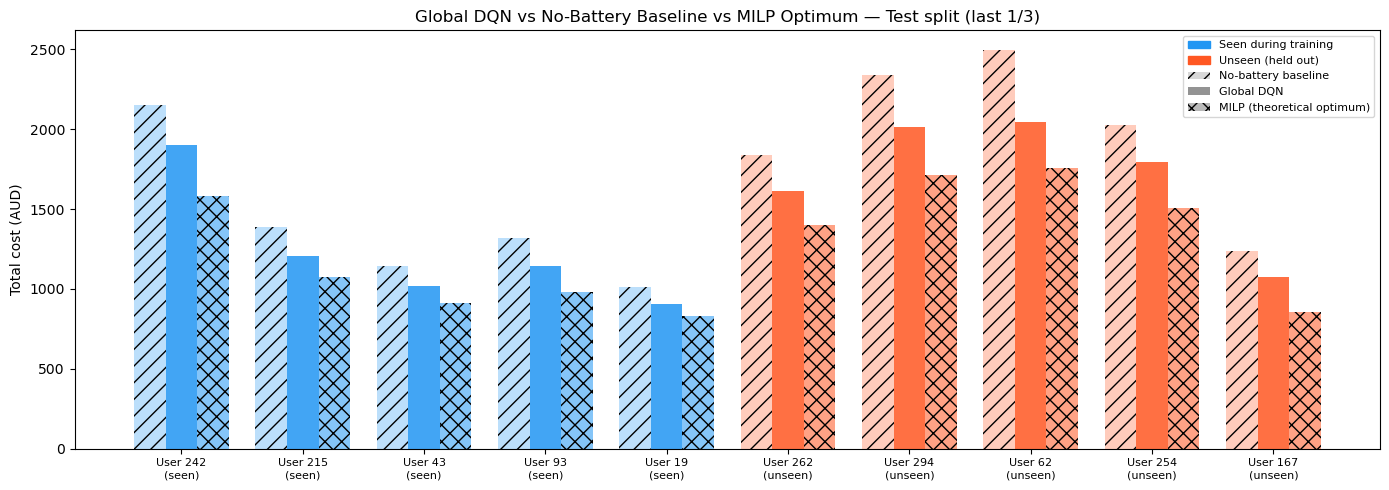

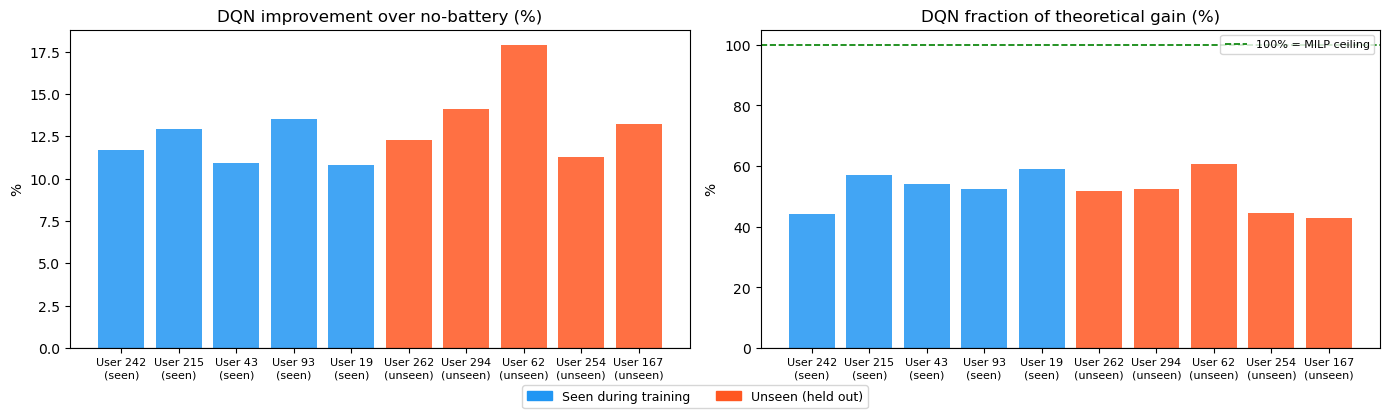

Plots saved: global_dqn_costs.png, global_dqn_improvement.png


In [14]:
# ── Per-user results table ───────────────────────────────────
display_cols = {
    'uid':               'User',
    'group':             'Group',
    'baseline_aud':      'No-battery (AUD)',
    'cost_aud':          'DQN (AUD)',
    'milp_aud':          'MILP optimum (AUD)',
    'imp_dqn_%':         'DQN impr. vs base (%)',
    'imp_milp_%':        'MILP impr. vs base (%)',
    'gap_dqn_vs_milp_%': 'DQN gap vs MILP (%)',
    'fraction_theor_%':  'DQN fraction of theor. gain (%)',
}
df_display = df_results[list(display_cols.keys())].rename(columns=display_cols)
print('═' * 120)
print('PER-USER RESULTS')
print('═' * 120)
print(df_display.to_string(index=False))

# ── Group averages ───────────────────────────────────────────
print('\n' + '═' * 80)
print('GROUP AVERAGES')
print('═' * 80)
group_avg = df_results.groupby('group').agg(
    N               = ('uid',               'count'),
    Baseline_AUD    = ('baseline_aud',      'mean'),
    DQN_AUD         = ('cost_aud',          'mean'),
    MILP_AUD        = ('milp_aud',          'mean'),
    DQN_impr_pct    = ('imp_dqn_%',         'mean'),
    MILP_impr_pct   = ('imp_milp_%',        'mean'),
    Gap_MILP_pct    = ('gap_dqn_vs_milp_%', 'mean'),
    Frac_theor_pct  = ('fraction_theor_%',  'mean'),
).round(2)
group_avg.columns = [
    'N', 'Baseline (AUD)', 'DQN (AUD)', 'MILP (AUD)',
    'DQN impr.%', 'MILP impr.%', 'DQN gap vs MILP%', 'Frac. of theor. gain%'
]
print(group_avg.to_string())

# ── Bar chart: absolute costs ────────────────────────────────
x          = np.arange(len(df_results))
width      = 0.26
colors     = {'seen': '#2196F3', 'unseen': '#FF5722'}
bar_colors = [colors[g] for g in df_results['group']]
xlabels    = [f'User {r.uid}\n({r.group})' for r in df_results.itertuples()]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width, df_results['baseline_aud'], width, color=bar_colors, alpha=0.30, hatch='//')
ax.bar(x,         df_results['cost_aud'],     width, color=bar_colors, alpha=0.85)
ax.bar(x + width, df_results['milp_aud'],     width, color=bar_colors, alpha=0.55, hatch='xx')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=8)
ax.set_ylabel('Total cost (AUD)')
ax.set_title('Global DQN vs No-Battery Baseline vs MILP Optimum — Test split (last 1/3)')
ax.legend(handles=[
    mpatches.Patch(color=colors['seen'],   label='Seen during training'),
    mpatches.Patch(color=colors['unseen'], label='Unseen (held out)'),
    mpatches.Patch(facecolor='grey', alpha=0.30, hatch='//', label='No-battery baseline'),
    mpatches.Patch(facecolor='grey', alpha=0.85,             label='Global DQN'),
    mpatches.Patch(facecolor='grey', alpha=0.55, hatch='xx', label='MILP (theoretical optimum)'),
], loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('global_dqn_costs.png', dpi=150)
plt.show()

# ── Two-panel improvement chart ──────────────────────────────
fig2, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 4))

ax_left.bar(x, df_results['imp_dqn_%'], color=bar_colors, alpha=0.85)
ax_left.axhline(0, color='black', linewidth=0.8)
ax_left.set_xticks(x); ax_left.set_xticklabels(xlabels, fontsize=8)
ax_left.set_ylabel('%'); ax_left.set_title('DQN improvement over no-battery (%)')

ax_right.bar(x, df_results['fraction_theor_%'], color=bar_colors, alpha=0.85)
ax_right.axhline(0,   color='black', linewidth=0.8)
ax_right.axhline(100, color='green', linewidth=1.2, linestyle='--', label='100% = MILP ceiling')
ax_right.set_xticks(x); ax_right.set_xticklabels(xlabels, fontsize=8)
ax_right.set_ylabel('%'); ax_right.set_title('DQN fraction of theoretical gain (%)')
ax_right.legend(fontsize=8)

fig2.legend(handles=[
    mpatches.Patch(color=colors['seen'],   label='Seen during training'),
    mpatches.Patch(color=colors['unseen'], label='Unseen (held out)'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=9)
plt.tight_layout()
plt.savefig('global_dqn_improvement.png', dpi=150)
plt.show()

print('Plots saved: global_dqn_costs.png, global_dqn_improvement.png')

## Cell 11 — Analyze 30 users from "Users_to analize.csv"


In [20]:
# Load the 30 users from CSV (stored in vertical format)
import re

with open('Users_to analize.csv', 'r') as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

# Skip header rows and find where actual data starts
start_idx = 0
for i, line in enumerate(lines):
    if line == '0':  # First cluster ID
        start_idx = i
        break

# Parse the vertical format: read in groups of 3
data = []
idx = start_idx
while idx < len(lines) and len(data) < 30:
    try:
        cluster = int(lines[idx])
        user_id = lines[idx + 1]
        dist = float(lines[idx + 2])
        data.append({'cluster': cluster, 'user_id': user_id, 'dist_to_centroid': dist})
        idx += 3
    except (ValueError, IndexError):
        break

df_users_to_analyze = pd.DataFrame(data)
print(f'Loaded {len(df_users_to_analyze)} users from CSV')
print(df_users_to_analyze.head(10))

# Extract numeric user IDs from "user_XXX" format
analyze_user_ids = []
for user_str in df_users_to_analyze['user_id']:
    uid = int(str(user_str).replace('user_', ''))
    analyze_user_ids.append(uid)

print(f'\nUser IDs to analyze: {len(analyze_user_ids)} users')
print(f'Sample IDs: {analyze_user_ids[:10]}')

# Check if any users were in training set
in_training = [uid for uid in analyze_user_ids if uid in train_ids]
held_out_from_training = [uid for uid in analyze_user_ids if uid not in train_ids]

print(f'\nUsers in training set: {len(in_training)} users')
print(f'Users held out from training: {len(held_out_from_training)} users')
if held_out_from_training:
    print(f'Held out IDs: {held_out_from_training}')


Loaded 30 users from CSV
   cluster   user_id  dist_to_centroid
0        0  user_138          0.587925
1        1  user_127          0.588956
2        2   user_65          0.484653
3        3  user_148          0.000000
4        4  user_223          0.000000
5        5  user_179          0.648130
6        6  user_261          0.670905
7        7  user_142          0.585771
8        8  user_128          0.570085
9        9  user_168          0.468785

User IDs to analyze: 30 users
Sample IDs: [138, 127, 65, 148, 223, 179, 261, 142, 128, 168]

Users in training set: 30 users
Users held out from training: 0 users


In [21]:
# Evaluate global DQN on 30 users to analyze
print('Evaluating global DQN on 30 users to analyze...\n')
results_30 = []

for uid in analyze_user_ids:
    try:
        cost     = evaluate_user(agent, uid, verbose=True)
        baseline = no_battery_baseline(uid)
        
        # Determine if user was in training
        group = 'trained' if uid in train_ids else 'held-out'
        
        results_30.append({
            'uid': uid, 
            'group': group, 
            'cost_aud': cost, 
            'baseline_aud': baseline,
            'cluster': df_users_to_analyze[df_users_to_analyze['user_id'] == f'user_{uid}']['cluster'].values[0] if len(df_users_to_analyze[df_users_to_analyze['user_id'] == f'user_{uid}']) > 0 else None
        })
    except Exception as e:
        print(f'  Error processing user {uid}: {e}')

df_results_30 = pd.DataFrame(results_30)
print(f'\nProcessed {len(df_results_30)} users successfully')


Evaluating global DQN on 30 users to analyze...

  User 138: 1560.50 AUD
  User 127: 1241.38 AUD
  User  65: 1439.56 AUD
  User 148: 1660.55 AUD
  User 223: 1194.69 AUD
  User 179: 1211.53 AUD
  User 261: 1053.96 AUD
  User 142: 1027.46 AUD
  User 128: 1350.82 AUD
  User 168: 989.43 AUD
  User 249: 1590.69 AUD
  User  81: 942.25 AUD
  User 104: 2621.59 AUD
  User 172: 1203.73 AUD
  User  29: 1224.58 AUD
  User  27: 1412.55 AUD
  User 156: 1562.45 AUD
  User 180: 1168.45 AUD
  User  21: 2009.68 AUD
  User 290: 1393.22 AUD
  User  66: 950.76 AUD
  User 240: 1137.17 AUD
  User 113: 1345.94 AUD
  User  67: 1220.86 AUD
  User   5: 1157.17 AUD
  User 158: 1527.25 AUD
  User   1: 1061.85 AUD
  User 204: 1138.95 AUD
  User 247: 1133.38 AUD
  User 137: 1508.36 AUD

Processed 30 users successfully


In [22]:
# Run MILP benchmark for the 30 users to analyze
print('Running MILP benchmark for 30 users to analyze (this will take several minutes)...\n')
milp_costs_30 = {}

for i, uid in enumerate(analyze_user_ids):
    try:
        cost = run_milp_for_user(uid, verbose=True)
        milp_costs_30[uid] = cost
    except Exception as e:
        print(f'  Error with MILP for user {uid}: {e}')
        milp_costs_30[uid] = None

# Merge MILP results
df_results_30['milp_aud'] = df_results_30['uid'].map(milp_costs_30)

# Compute comparison metrics
df_results_30['imp_dqn_%']         = ((df_results_30['baseline_aud'] - df_results_30['cost_aud'])  / df_results_30['baseline_aud'] * 100).round(1)
df_results_30['imp_milp_%']        = ((df_results_30['baseline_aud'] - df_results_30['milp_aud'])  / df_results_30['baseline_aud'] * 100).round(1)
df_results_30['gap_dqn_vs_milp_%'] = ((df_results_30['cost_aud']     - df_results_30['milp_aud'])  / df_results_30['milp_aud']     * 100).round(1)
df_results_30['fraction_theor_%']  = ((df_results_30['baseline_aud'] - df_results_30['cost_aud'])  / (df_results_30['baseline_aud'] - df_results_30['milp_aud']) * 100).round(1)

print('\nMILP benchmark complete.')


Running MILP benchmark for 30 users to analyze (this will take several minutes)...

  User 138 MILP: 1250.01 AUD
  User 127 MILP: 1119.71 AUD
  User  65 MILP: 1233.60 AUD
  User 148 MILP: 1372.17 AUD
  User 223 MILP: 1027.88 AUD
  User 179 MILP: 1076.89 AUD
  User 261 MILP: 956.42 AUD
  User 142 MILP: 852.29 AUD
  User 128 MILP: 1207.66 AUD
  User 168 MILP: 889.77 AUD
  User 249 MILP: 1336.96 AUD
  User  81 MILP: 822.67 AUD
  User 104 MILP: 2268.69 AUD
  User 172 MILP: 1071.80 AUD
  User  29 MILP: 1040.62 AUD
  User  27 MILP: 1228.09 AUD
  User 156 MILP: 1342.51 AUD
  User 180 MILP: 993.51 AUD
  User  21 MILP: 1703.62 AUD
  User 290 MILP: 1224.31 AUD
  User  66 MILP: 845.94 AUD
  User 240 MILP: 990.14 AUD
  User 113 MILP: 1170.76 AUD
  User  67 MILP: 972.43 AUD
  User   5 MILP: 1038.65 AUD
  User 158 MILP: 1214.16 AUD
  User   1 MILP: 784.81 AUD
  User 204 MILP: 1006.82 AUD
  User 247 MILP: 1018.96 AUD
  User 137 MILP: 1291.31 AUD

MILP benchmark complete.


In [23]:
# Display results for 30 users
print('═' * 140)
print('RESULTS FOR 30 USERS TO ANALYZE')
print('═' * 140)

display_cols_30 = {
    'uid':               'User',
    'group':             'Group',
    'cluster':           'Cluster',
    'baseline_aud':      'No-battery (AUD)',
    'cost_aud':          'DQN (AUD)',
    'milp_aud':          'MILP optimum (AUD)',
    'imp_dqn_%':         'DQN impr. vs base (%)',
    'imp_milp_%':        'MILP impr. vs base (%)',
    'gap_dqn_vs_milp_%': 'DQN gap vs MILP (%)',
    'fraction_theor_%':  'DQN fraction of theor. gain (%)',
}

df_display_30 = df_results_30[list(display_cols_30.keys())].rename(columns=display_cols_30)
print(df_display_30.to_string(index=False))

# Group statistics
print('\n' + '═' * 100)
print('GROUP STATISTICS FOR 30 USERS')
print('═' * 100)

group_stats_30 = df_results_30.groupby('group').agg(
    N               = ('uid',               'count'),
    Baseline_AUD    = ('baseline_aud',      'mean'),
    DQN_AUD         = ('cost_aud',          'mean'),
    MILP_AUD        = ('milp_aud',          'mean'),
    DQN_impr_pct    = ('imp_dqn_%',         'mean'),
    MILP_impr_pct   = ('imp_milp_%',        'mean'),
    Gap_MILP_pct    = ('gap_dqn_vs_milp_%', 'mean'),
    Frac_theor_pct  = ('fraction_theor_%',  'mean'),
).round(2)

group_stats_30.columns = [
    'N', 'Baseline (AUD)', 'DQN (AUD)', 'MILP (AUD)',
    'DQN impr.%', 'MILP impr.%', 'DQN gap vs MILP%', 'Frac. of theor. gain%'
]
print(group_stats_30.to_string())

# By cluster statistics
print('\n' + '═' * 100)
print('STATISTICS BY CLUSTER')
print('═' * 100)

cluster_stats_30 = df_results_30.groupby('cluster').agg(
    N               = ('uid',               'count'),
    Baseline_AUD    = ('baseline_aud',      'mean'),
    DQN_AUD         = ('cost_aud',          'mean'),
    MILP_AUD        = ('milp_aud',          'mean'),
    DQN_impr_pct    = ('imp_dqn_%',         'mean'),
    MILP_impr_pct   = ('imp_milp_%',        'mean'),
    Gap_MILP_pct    = ('gap_dqn_vs_milp_%', 'mean'),
    Frac_theor_pct  = ('fraction_theor_%',  'mean'),
).round(2)

cluster_stats_30.columns = [
    'N', 'Baseline (AUD)', 'DQN (AUD)', 'MILP (AUD)',
    'DQN impr.%', 'MILP impr.%', 'DQN gap vs MILP%', 'Frac. of theor. gain%'
]
print(cluster_stats_30.to_string())

# Overall statistics
print('\n' + '═' * 100)
print('OVERALL STATISTICS (30 USERS)')
print('═' * 100)
print(f'Average baseline cost (no-battery):      {df_results_30["baseline_aud"].mean():.2f} AUD')
print(f'Average DQN cost:                        {df_results_30["cost_aud"].mean():.2f} AUD')
print(f'Average MILP cost (optimum):             {df_results_30["milp_aud"].mean():.2f} AUD')
print(f'Average DQN improvement over baseline:   {df_results_30["imp_dqn_%"].mean():.2f}%')
print(f'Average MILP improvement over baseline:  {df_results_30["imp_milp_%"].mean():.2f}%')
print(f'Average DQN gap vs MILP:                 {df_results_30["gap_dqn_vs_milp_%"].mean():.2f}%')
print(f'Average DQN fraction of theoretical:     {df_results_30["fraction_theor_%"].mean():.2f}%')


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
RESULTS FOR 30 USERS TO ANALYZE
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
 User   Group  Cluster  No-battery (AUD)   DQN (AUD)  MILP optimum (AUD)  DQN impr. vs base (%)  MILP impr. vs base (%)  DQN gap vs MILP (%)  DQN fraction of theor. gain (%)
  138 trained        0       1733.651120 1560.503528         1250.011600                   10.0                    27.9                 24.8                             35.8
  127 trained        1       1421.494479 1241.375275         1119.709874                   12.7                    21.2                 10.9                             59.7
   65 trained        2       1649.153475 1439.563110         1233.602548                   12.7                    25.2                 16.7                        

### Visualizations for 30 users


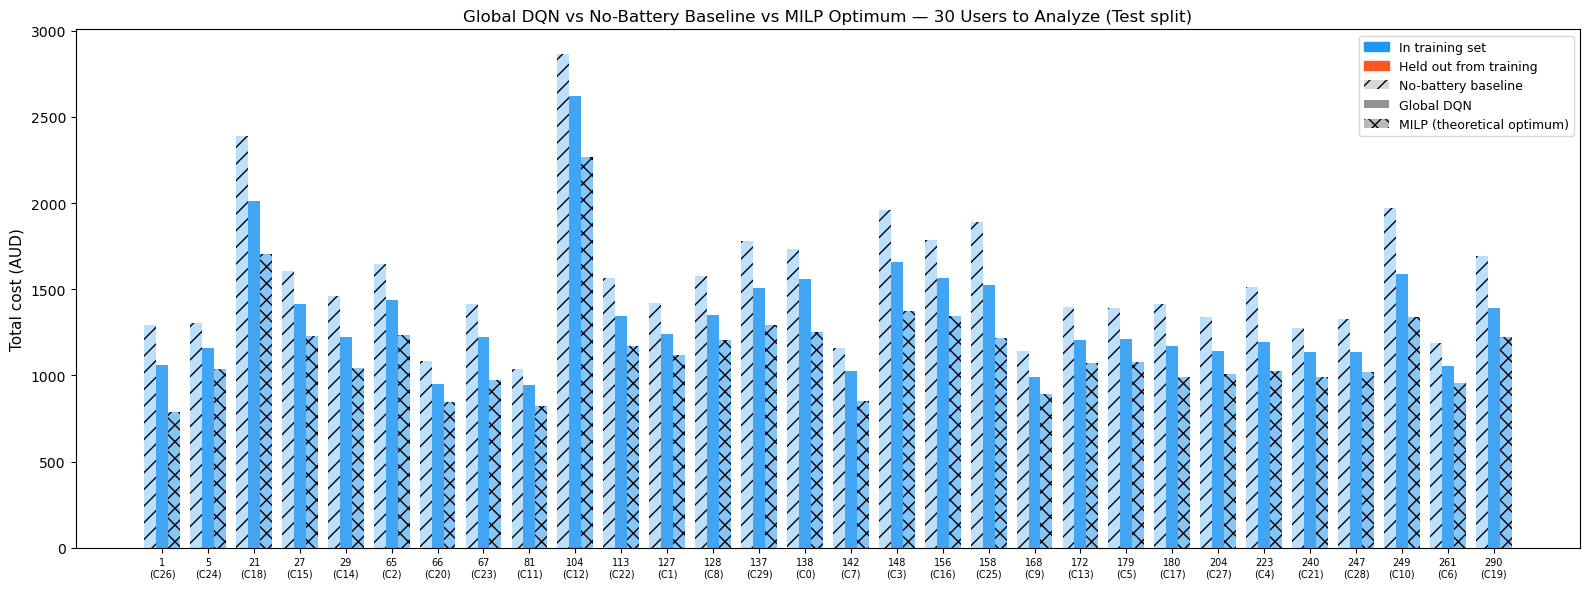

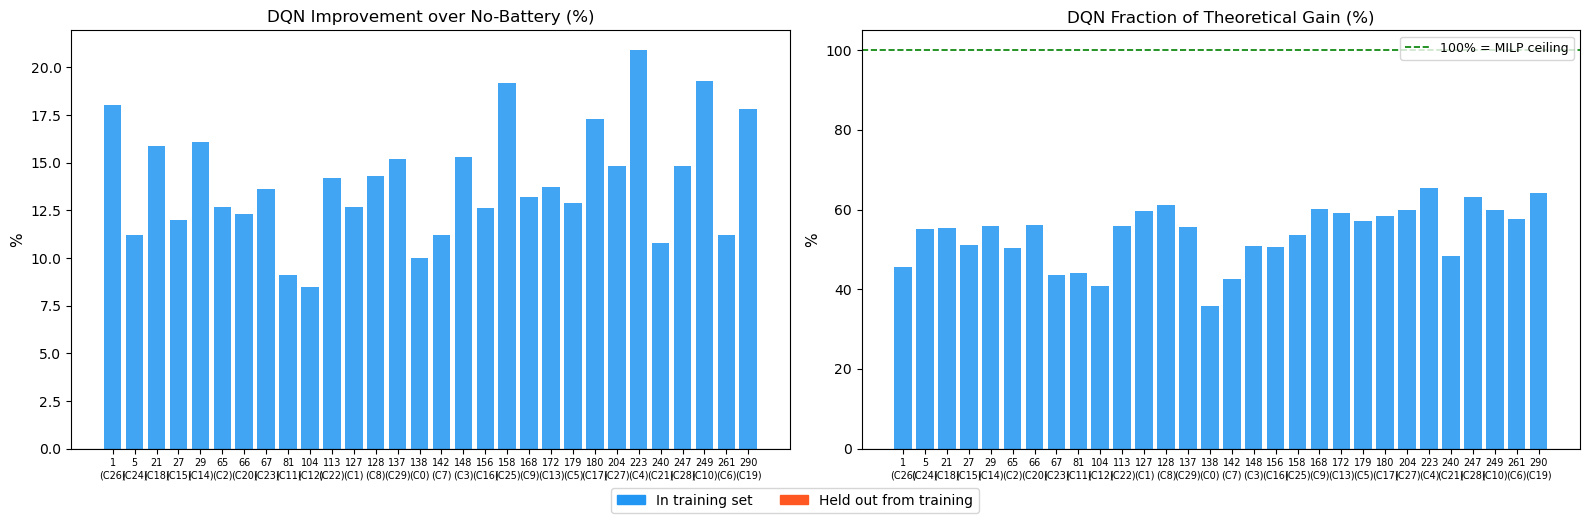

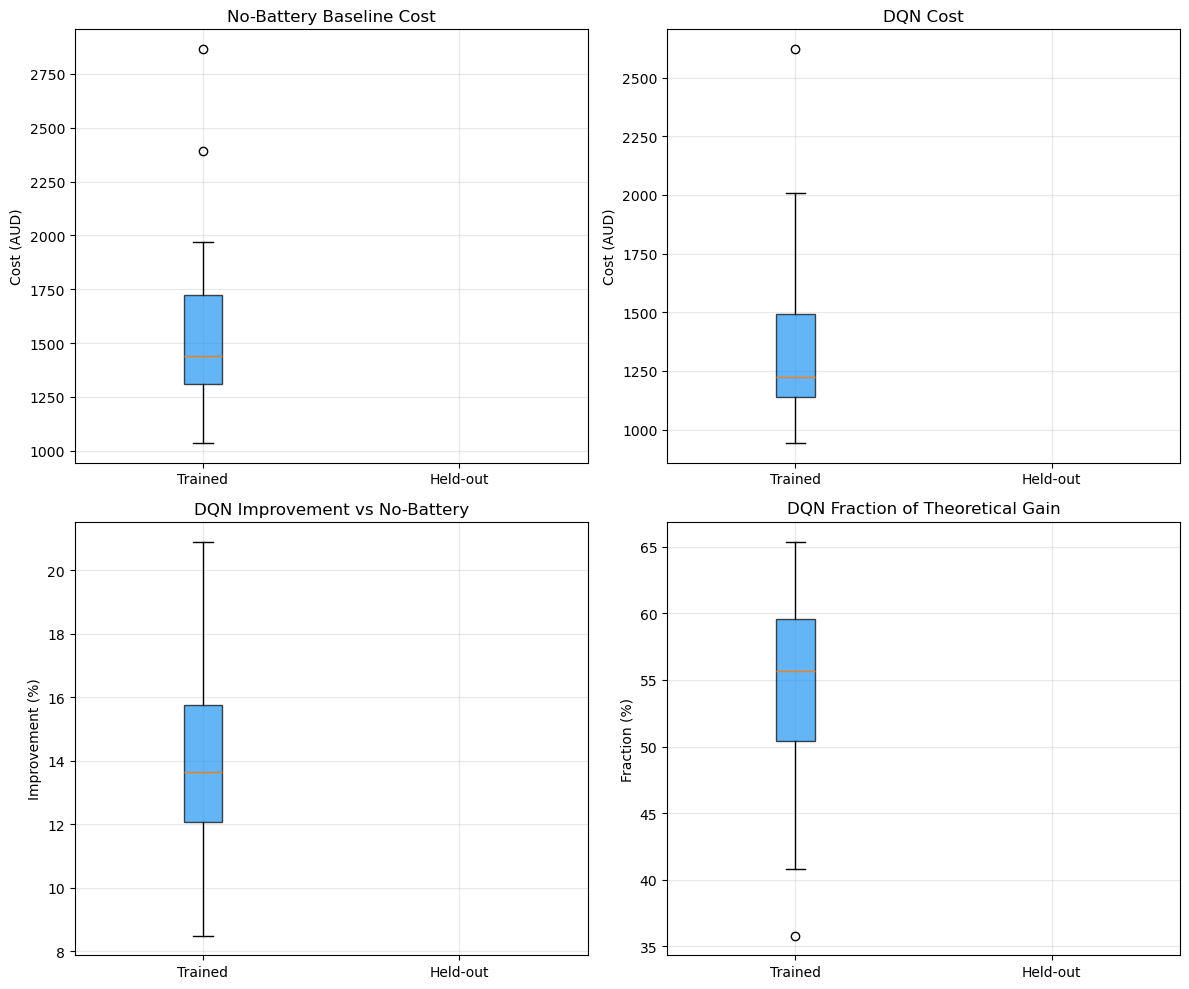

Plots saved: global_dqn_30users_costs.png, global_dqn_30users_improvement.png, global_dqn_30users_boxplots.png


In [24]:
# Bar chart: absolute costs for 30 users sorted by user ID
df_results_30_sorted = df_results_30.sort_values('uid').reset_index(drop=True)
x = np.arange(len(df_results_30_sorted))
width = 0.26
colors = {'trained': '#2196F3', 'held-out': '#FF5722'}
bar_colors = [colors[g] for g in df_results_30_sorted['group']]
xlabels = [f'{r.uid}\n(C{int(r.cluster)})' for r in df_results_30_sorted.itertuples()]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width, df_results_30_sorted['baseline_aud'], width, color=bar_colors, alpha=0.30, hatch='//')
ax.bar(x,         df_results_30_sorted['cost_aud'],     width, color=bar_colors, alpha=0.85)
ax.bar(x + width, df_results_30_sorted['milp_aud'],     width, color=bar_colors, alpha=0.55, hatch='xx')
ax.set_xticks(x)
ax.set_xticklabels(xlabels, fontsize=7)
ax.set_ylabel('Total cost (AUD)', fontsize=11)
ax.set_title('Global DQN vs No-Battery Baseline vs MILP Optimum — 30 Users to Analyze (Test split)', fontsize=12)
ax.legend(handles=[
    mpatches.Patch(color=colors['trained'],   label='In training set'),
    mpatches.Patch(color=colors['held-out'], label='Held out from training'),
    mpatches.Patch(facecolor='grey', alpha=0.30, hatch='//', label='No-battery baseline'),
    mpatches.Patch(facecolor='grey', alpha=0.85,             label='Global DQN'),
    mpatches.Patch(facecolor='grey', alpha=0.55, hatch='xx', label='MILP (theoretical optimum)'),
], loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('global_dqn_30users_costs.png', dpi=150)
plt.show()

# Improvement comparison
fig2, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 5))

ax_left.bar(x, df_results_30_sorted['imp_dqn_%'], color=bar_colors, alpha=0.85)
ax_left.axhline(0, color='black', linewidth=0.8)
ax_left.set_xticks(x); ax_left.set_xticklabels(xlabels, fontsize=7)
ax_left.set_ylabel('%', fontsize=11); ax_left.set_title('DQN Improvement over No-Battery (%)', fontsize=12)

ax_right.bar(x, df_results_30_sorted['fraction_theor_%'], color=bar_colors, alpha=0.85)
ax_right.axhline(0,   color='black', linewidth=0.8)
ax_right.axhline(100, color='green', linewidth=1.2, linestyle='--', label='100% = MILP ceiling')
ax_right.set_xticks(x); ax_right.set_xticklabels(xlabels, fontsize=7)
ax_right.set_ylabel('%', fontsize=11); ax_right.set_title('DQN Fraction of Theoretical Gain (%)', fontsize=12)
ax_right.legend(fontsize=9)

fig2.legend(handles=[
    mpatches.Patch(color=colors['trained'],   label='In training set'),
    mpatches.Patch(color=colors['held-out'], label='Held out from training'),
], loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=10)
plt.tight_layout()
plt.savefig('global_dqn_30users_improvement.png', dpi=150)
plt.show()

# Box plots by group
fig3, axes = plt.subplots(2, 2, figsize=(12, 10))

# Cost comparison
ax = axes[0, 0]
data_to_plot = [df_results_30[df_results_30['group'] == g]['baseline_aud'].values for g in ['trained', 'held-out']]
bp1 = ax.boxplot(data_to_plot, labels=['Trained', 'Held-out'], patch_artist=True)
for patch, color in zip(bp1['boxes'], [colors['trained'], colors['held-out']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Cost (AUD)'); ax.set_title('No-Battery Baseline Cost'); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
data_to_plot = [df_results_30[df_results_30['group'] == g]['cost_aud'].values for g in ['trained', 'held-out']]
bp2 = ax.boxplot(data_to_plot, labels=['Trained', 'Held-out'], patch_artist=True)
for patch, color in zip(bp2['boxes'], [colors['trained'], colors['held-out']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Cost (AUD)'); ax.set_title('DQN Cost'); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
data_to_plot = [df_results_30[df_results_30['group'] == g]['imp_dqn_%'].values for g in ['trained', 'held-out']]
bp3 = ax.boxplot(data_to_plot, labels=['Trained', 'Held-out'], patch_artist=True)
for patch, color in zip(bp3['boxes'], [colors['trained'], colors['held-out']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Improvement (%)'); ax.set_title('DQN Improvement vs No-Battery'); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
data_to_plot = [df_results_30[df_results_30['group'] == g]['fraction_theor_%'].values for g in ['trained', 'held-out']]
bp4 = ax.boxplot(data_to_plot, labels=['Trained', 'Held-out'], patch_artist=True)
for patch, color in zip(bp4['boxes'], [colors['trained'], colors['held-out']]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Fraction (%)'); ax.set_title('DQN Fraction of Theoretical Gain'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('global_dqn_30users_boxplots.png', dpi=150)
plt.show()

print('Plots saved: global_dqn_30users_costs.png, global_dqn_30users_improvement.png, global_dqn_30users_boxplots.png')


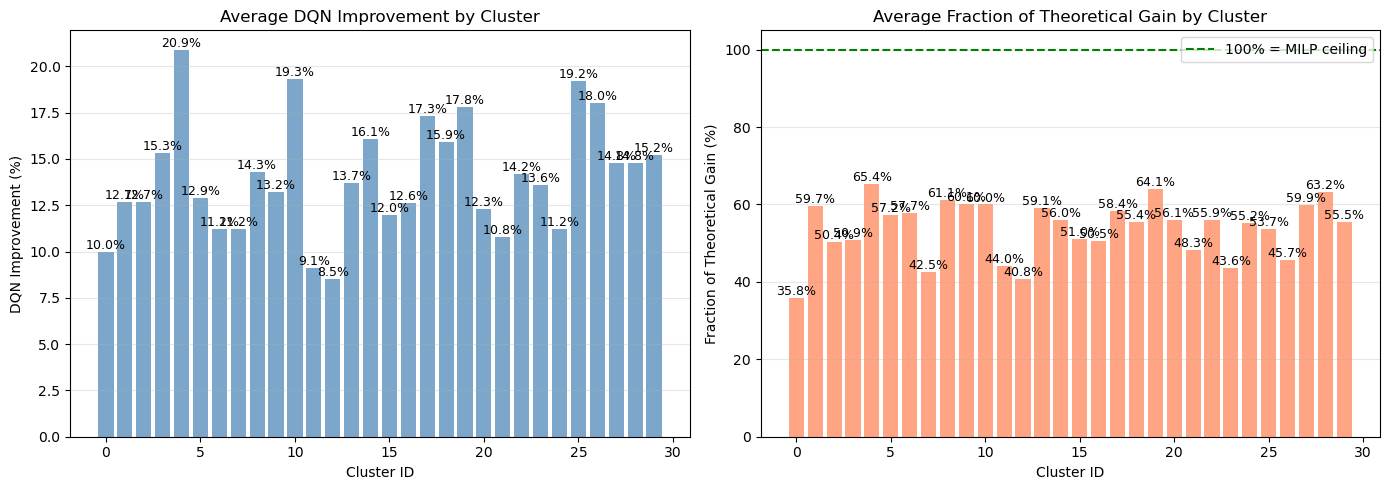


════════════════════════════════════════════════════════════════════════════════════════════════════
COMPARISON: 10 INITIAL EVAL USERS vs 30 ANALYSIS USERS
════════════════════════════════════════════════════════════════════════════════════════════════════

10 Initial Evaluation Users:
  DQN Improvement (avg):        12.86%
  Fraction of Theoretical (avg): 51.84%
  Gap vs MILP (avg):            16.36%

30 Analysis Users:
  DQN Improvement (avg):        14.03%
  Fraction of Theoretical (avg): 53.91%
  Gap vs MILP (avg):            16.57%

30 Analysis Users - Trained subset (30 users):
  DQN Improvement (avg):        14.03%
  Fraction of Theoretical (avg): 53.91%

30 Analysis Users - Held-out subset (0 users):
  DQN Improvement (avg):        nan%
  Fraction of Theoretical (avg): nan%

Plots saved: global_dqn_30users_by_cluster.png


In [25]:
# Cluster-based visualization
fig4, axes = plt.subplots(1, 2, figsize=(14, 5))

# DQN improvement by cluster
ax = axes[0]
cluster_improvement = df_results_30.groupby('cluster')['imp_dqn_%'].mean().sort_index()
bars = ax.bar(cluster_improvement.index, cluster_improvement.values, color='steelblue', alpha=0.7)
ax.set_xlabel('Cluster ID'); ax.set_ylabel('DQN Improvement (%)')
ax.set_title('Average DQN Improvement by Cluster'); ax.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Fraction of theoretical gain by cluster
ax = axes[1]
cluster_fraction = df_results_30.groupby('cluster')['fraction_theor_%'].mean().sort_index()
bars = ax.bar(cluster_fraction.index, cluster_fraction.values, color='coral', alpha=0.7)
ax.axhline(100, color='green', linestyle='--', linewidth=1.5, label='100% = MILP ceiling')
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Fraction of Theoretical Gain (%)')
ax.set_title('Average Fraction of Theoretical Gain by Cluster'); ax.grid(True, alpha=0.3, axis='y')
ax.legend()
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('global_dqn_30users_by_cluster.png', dpi=150)
plt.show()

# Summary comparison: 10 eval users vs 30 analysis users
print('\n' + '═' * 100)
print('COMPARISON: 10 INITIAL EVAL USERS vs 30 ANALYSIS USERS')
print('═' * 100)

print('\n10 Initial Evaluation Users:')
print(f'  DQN Improvement (avg):        {df_results["imp_dqn_%"].mean():.2f}%')
print(f'  Fraction of Theoretical (avg): {df_results["fraction_theor_%"].mean():.2f}%')
print(f'  Gap vs MILP (avg):            {df_results["gap_dqn_vs_milp_%"].mean():.2f}%')

print('\n30 Analysis Users:')
print(f'  DQN Improvement (avg):        {df_results_30["imp_dqn_%"].mean():.2f}%')
print(f'  Fraction of Theoretical (avg): {df_results_30["fraction_theor_%"].mean():.2f}%')
print(f'  Gap vs MILP (avg):            {df_results_30["gap_dqn_vs_milp_%"].mean():.2f}%')

print(f'\n30 Analysis Users - Trained subset ({len(df_results_30[df_results_30["group"]=="trained"])} users):')
print(f'  DQN Improvement (avg):        {df_results_30[df_results_30["group"]=="trained"]["imp_dqn_%"].mean():.2f}%')
print(f'  Fraction of Theoretical (avg): {df_results_30[df_results_30["group"]=="trained"]["fraction_theor_%"].mean():.2f}%')

print(f'\n30 Analysis Users - Held-out subset ({len(df_results_30[df_results_30["group"]=="held-out"])} users):')
print(f'  DQN Improvement (avg):        {df_results_30[df_results_30["group"]=="held-out"]["imp_dqn_%"].mean():.2f}%')
print(f'  Fraction of Theoretical (avg): {df_results_30[df_results_30["group"]=="held-out"]["fraction_theor_%"].mean():.2f}%')

print('\nPlots saved: global_dqn_30users_by_cluster.png')
